In [1]:
# This script identifies water molecules that permeate through the
# nanotube layer

In [2]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- region of crossing ---
upper_end = 6.754
lower_end = -6.754

In [4]:
# Start counting permeation events after this number of frames
skip_frame = 0
output_file = "permeation.dat"

In [5]:
# Load your trajectory (replace with your own files)
u = mda.Universe('../input/system.psf','MDequil.dcd')
wat = u.select_atoms("name OH2")

/opt/anaconda3/envs/nanociencia/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [6]:
seg_list = wat.segids  # Per-atom segid
resids = wat.resids    # Per-atom resid
num_atoms = len(wat)
labels = np.zeros(num_atoms, dtype=int)

In [7]:
num1 = 0  # +z direction count
num2 = 0  # -z direction count

In [8]:
# Each water molecule has a label, which has 5 possible values
#  2: Above the nanotube layer
# -2: Below the nanotube layer
#  1: Inside the nanotube layer, entering from upper surface
# -1: Inside the nanotube layer, entering from lower surface
#  0: Inside the nanotube layer from the beginning

In [9]:
# For every frame, the label of each water molecule is
# determined, and compared with its label in the previous frame.
# If the new label is +2 (or -2), while the old label is -1 (or +1),
# it means the water molecule has traversed the nanotube, thus a
# permeation event is reported and counted. If a water molecule
# is inside the nanotube layer in the current frame, its label
# will be determined by its old label.

In [10]:
print("Computing permeation events... (please wait)")

Computing permeation events... (please wait)


In [11]:
time=[]
permeation_pos=[]
permeation_neg=[]

In [13]:
with open(output_file, "w") as f:
    f.write("# frame +z -z \n")

    for ts in u.trajectory:
        z_coords = wat.positions[:, 2]
        old_labels = labels.copy()
        for i, z in enumerate(z_coords):
            old_label = old_labels[i]
            segname = seg_list[i]
            resid = resids[i]

            if z > upper_end:
                new_label = 2
                if old_label == -1:
                    print(f"{segname}:{resid} permeated through the nanotubes along +z direction at frame {ts.frame}")
                    if ts.frame >= skip_frame:
                        num1 += 1
            elif z < lower_end:
                new_label = -2
                if old_label == 1:
                    print(f"{segname}:{resid} permeated through the nanotubes along -z direction at frame {ts.frame}")
                    if ts.frame >= skip_frame:
                        num2 += 1
            elif abs(old_label) > 1:
                new_label = old_label // 2
            else:
                new_label = old_label

            labels[i] = new_label

        # accumulate data to plot
        time.append(ts.time)
        permeation_pos.append(num1)
        permeation_neg.append(num2)
        # Save data to file
        f.write(f"{round(ts.time)} {num1} {num2}\n")

WT1:1873 permeated through the nanotubes along -z direction at frame 3
WT1:1831 permeated through the nanotubes along -z direction at frame 7
WT1:4012 permeated through the nanotubes along -z direction at frame 8
WT1:1707 permeated through the nanotubes along -z direction at frame 12
WT1:8528 permeated through the nanotubes along -z direction at frame 25
WT1:3246 permeated through the nanotubes along +z direction at frame 31
WT1:4543 permeated through the nanotubes along +z direction at frame 31
WT1:1911 permeated through the nanotubes along -z direction at frame 37
WT1:1328 permeated through the nanotubes along -z direction at frame 39
WT1:2715 permeated through the nanotubes along -z direction at frame 39
WT1:1744 permeated through the nanotubes along -z direction at frame 40
WT1:5356 permeated through the nanotubes along -z direction at frame 43
WT1:7634 permeated through the nanotubes along +z direction at frame 43
WT1:1987 permeated through the nanotubes along +z direction at fram

In [14]:
# Summary
nf = len(u.trajectory) - skip_frame
if nf >= 0:
    print(f"\nThe total number of permeation events during {nf} frames in +z direction is: {num1}")
    print(f"The total number of permeation events during {nf} frames in -z direction is: {num2}")
else:
    print(f"The specified first frame ({skip_frame}) is larger than the total number of frames.")


The total number of permeation events during 100 frames in +z direction is: 10
The total number of permeation events during 100 frames in -z direction is: 11


In [15]:
print("Time evolution saved in a .dat file")

Time evolution saved in a .dat file


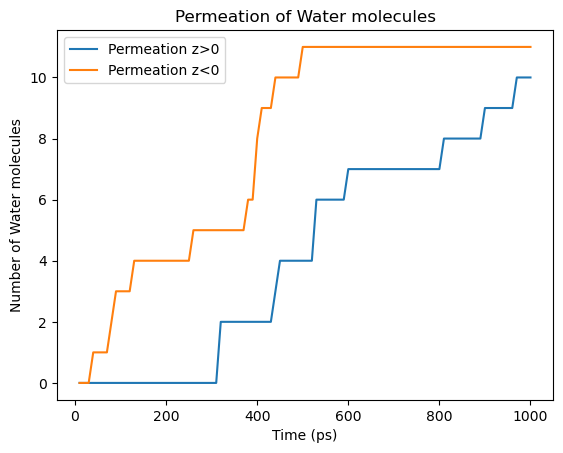

In [16]:
#Plot
plt.plot(time, permeation_pos, label='Permeation z>0')
plt.plot(time, permeation_neg, label='Permeation z<0')
plt.xlabel('Time (ps)')
plt.ylabel('Number of Water molecules')
plt.title('Permeation of Water molecules')
plt.legend()
plt.show()

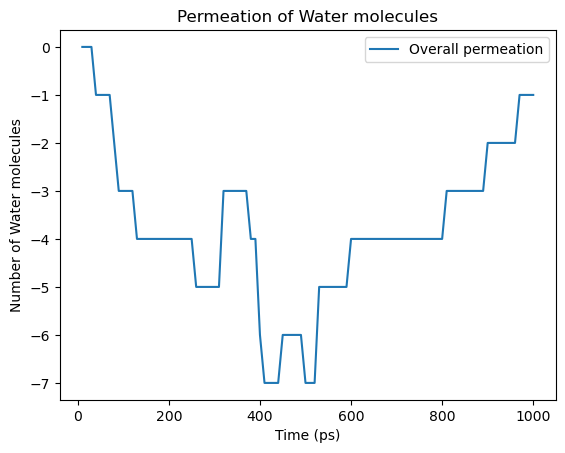

In [17]:
#plot overall permeation (one direction minos opposite direction)
overall= [permeation_pos - permeation_neg for permeation_pos, permeation_neg in zip(permeation_pos, permeation_neg)]
plt.plot(time, overall, label='Overall permeation')
plt.xlabel('Time (ps)')
plt.ylabel('Number of Water molecules')
plt.title('Permeation of Water molecules')
plt.legend()
plt.show()